In [1]:
import sys
sys.path.append('../src/pinn')
sys.path.append('../src/data_generation')

In [2]:
import jax
import jax.numpy as jnp
import os
import numpy as np
import matplotlib.pyplot as plt
from pinn.train import create_train_state, train_step
from pinn.cryoet_io import load_mrc_data
import pickle
from flax.training import checkpoints
from pinn.utils import initial_loss
from pinn.train import train_step
from tqdm.notebook import trange

GRID_SIZE = 64
NUM_CHECKPOINTS_TO_KEEP = 1000  # Checkpoint retention count (older ones get removed)

# Set loss function weights
lambda_1 = 1000000      # Weight for boundary loss
lambda_2 = 100         # Weight for physics loss


# Initialize JAX random key
key = jax.random.PRNGKey(0)

# Set directory for initial condition
# ckpt_dir = os.path.abspath(f"../outputs/logs/test_phase/snwitch2-2/30000/default")
# ckpt_dir = os.path.abspath(f"../outputs/logs/biconcave/round_1/lambda_5000000_1e-05/checkpoint_30000/")
# init_ckpt = checkpoints.restore_checkpoint(ckpt_dir=ckpt_dir, target=None)

# Create train state
# state, model = create_train_state(key, lambda_1=lambda_1, lambda_2=lambda_2, sdf_pretrain=False, learning_rate=1e-3, init_ckpt=init_ckpt)
state, model = create_train_state(key, lambda_1=lambda_1, lambda_2=lambda_2, sdf_pretrain=True, learning_rate=1e-3)
print(f"Using lambda_1: {state.lambda_1}, lambda_2: {state.lambda_2}")

# Load MRC data
# mrc_file_path = "../data/experimental/downsampled/TS_105_7.mrc"
mrc_file_path = "../data/experimental/downsampled/27042022_BrnoKrios_Arctis_grid9_hGIS_Position_44.mrc"

cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)
print("MRC data loaded successfully! Shape:", cryoET_data.shape)
print("Cryo-ET Data Shape:", cryoET_data.shape)
print("Cryo-ET Data Min:", cryoET_data.min())
print("Cryo-ET Data Max:", cryoET_data.max())
print("Cryo-ET Unique Values:", jnp.unique(cryoET_data))

# Training Data
num_collocation = 10000
x_train = (jax.random.uniform(key, (num_collocation, 3), minval=-1, maxval=1)) # Sampled from [-1, 1]^3


# Training loop
num_steps = 1000
save_interval = 100


# temporary 
binary_mask = jnp.where(cryoET_data > 0.8, 1, 0)
membrane_indices = jnp.where(binary_mask.ravel() == 1)[0]

checkpoint_dir = os.path.abspath(f"../outputs/logs/experimental/lambda_{lambda_1}_{lambda_2}")

checkpoints.save_checkpoint(
    ckpt_dir=checkpoint_dir,
    # target={"state": state, "loss": initial_loss(state, x_train, cryoET_data)},
    target={"state": state, "loss": initial_loss(state, x_train, cryoET_data, membrane_indices)},
    step=0,
    overwrite=False, 
    keep=NUM_CHECKPOINTS_TO_KEEP,
)
loss_history = []


# for step in range(num_steps):
for step in trange(num_steps):
    # state, loss_val, loss_data_val, loss_physics_val = train_step(state, x_train, cryoET_data)
    state, loss_val, loss_data_val, loss_physics_val = train_step(state, x_train, cryoET_data, membrane_indices)

    loss_history.append({
        "step": step + 1,
        "total_loss": loss_val,
        "data_loss": loss_data_val,
        "physics_loss": loss_physics_val
    })

    if (step+1) % save_interval == 0:

        loss_history = {key: np.array([entry[key] for entry in loss_history]) for key in loss_history[0].keys()}
        
        checkpoints.save_checkpoint(
            ckpt_dir = checkpoint_dir,
            target={"state": state, "loss": loss_history},
            step=step+1, 
            overwrite=False, 
            keep=NUM_CHECKPOINTS_TO_KEEP,
        )
        print(f"Checkpoint saved at step {step+1}")

        loss_history = []


Pretraining the network using SDF...
Using lambda_1: 1000000, lambda_2: 100
MRC data loaded successfully! Shape: (64, 64, 64)
Cryo-ET Data Shape: (64, 64, 64)
Cryo-ET Data Min: 0.0
Cryo-ET Data Max: 1.0
Cryo-ET Unique Values: [0.         0.0155211  0.02281747 ... 0.99998677 0.9999924  1.        ]


  0%|          | 0/1000 [00:00<?, ?it/s]

Checkpoint saved at step 100
Checkpoint saved at step 200
Checkpoint saved at step 300
Checkpoint saved at step 400
Checkpoint saved at step 500
Checkpoint saved at step 600
Checkpoint saved at step 700
Checkpoint saved at step 800
Checkpoint saved at step 900
Checkpoint saved at step 1000


## Analysis

/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/experimental/lambda_1000000_100


/gscratch/matsulab/env/pinn-env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


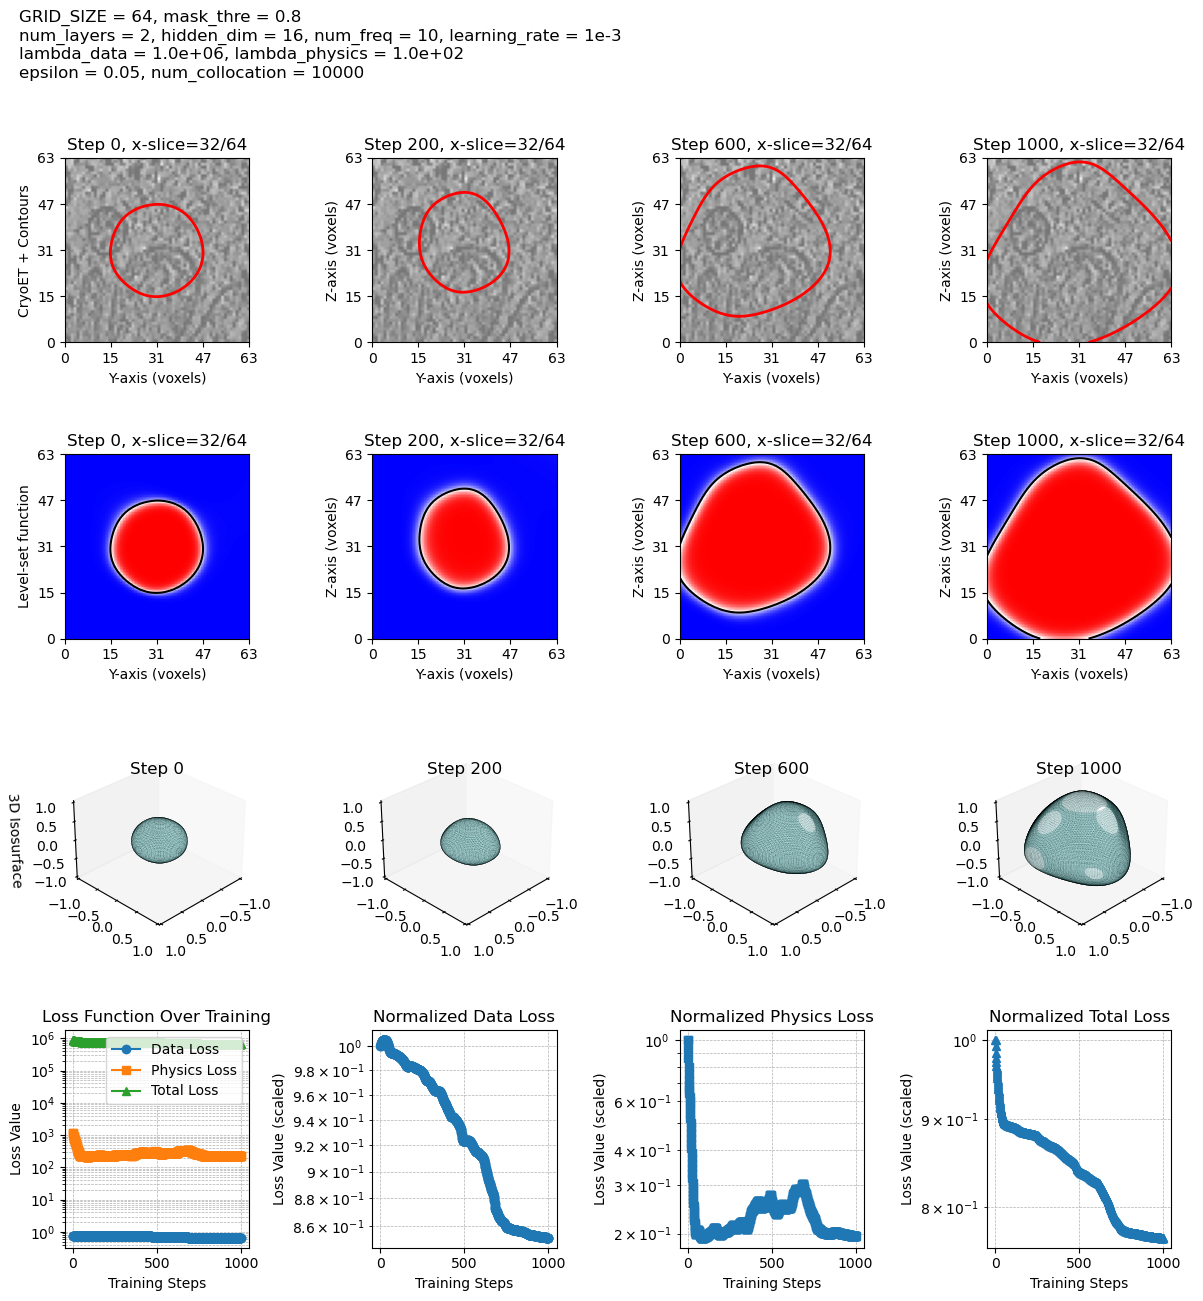

In [3]:
## make one combined image file

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    visualize_checkpoint_result,
    visualize_cryoET_with_contours,
    plot_3d_isosurface,
    plot_loss_history_ax,
    plot_normalized_loss_history_ax,
)
from pinn.utils import assemble_loss_history

GRID_SIZE = 64
# lambda_1 = 1000000
# lambda_2 = 100
num_collocation = 10000
num_layers = 2


steps_to_visualize = [0, 200, 600, 1000]
steps_series = list(range(0, 1001, 100))
# steps_to_visualize = [0, 100, 1000, 10000]
# steps_series = list(range(0, 10001, 100))

# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/experimental/lambda_{lambda_1}_{lambda_2}")
print(checkpoint_dir)
checkpoint_data = {}
for step in steps_series:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Load CryoET data
mrc_file_path = "../data/experimental/downsampled/27042022_BrnoKrios_Arctis_grid9_hGIS_Position_44.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

# Create a big figure with 4 rows: cryoET + contours, prediction result, 3D isosurface, and leave room for loss plots
fig = plt.figure(figsize=(3*4, 12))

# Row 1: visualize_cryoET_with_contours
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, i + 1)
    visualize_cryoET_with_contours(ax, step, checkpoint_data[step], cryoET_data, grid_size=GRID_SIZE, slice_index=32, axis="x", thresholding=False)
    if i == 0:
        ax.set_ylabel("CryoET + Contours")

# Row 2: visualize_checkpoint_result
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 4 + i + 1)
    visualize_checkpoint_result(ax, step, checkpoint_data[step], grid_size=GRID_SIZE, slice_index=32, axis="x")
    if i == 0:
        ax.set_ylabel("Level-set function")

# Row 3: plot_3d_isosurface
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 8 + i + 1, projection='3d')
    plot_3d_isosurface(ax, step, checkpoint_data[step], grid_size=GRID_SIZE)
    if i == 0:
        ax.set_zlabel("3D Isosurface", rotation=180)

# Row 4: loss history
assembled_loss = assemble_loss_history(checkpoint_data)
ax = fig.add_subplot(4, 4, 12+1)
plot_loss_history_ax(ax, assembled_loss)
for i in [0,1,2]:
    ax = fig.add_subplot(4, 4, 12+i+2)
    plot_normalized_loss_history_ax(ax, i, assembled_loss)
    

info_text = (
    f"GRID_SIZE = {GRID_SIZE}, mask_thre = 0.8\n"
    f"num_layers = {num_layers}, hidden_dim = 16, num_freq = 10, learning_rate = 1e-3\n"
    f"lambda_data = {lambda_1:.1e}, lambda_physics = {lambda_2:.1e}\n"
    f"epsilon = 0.05, num_collocation = {num_collocation}"
)

fig.text(
    0.02, 1.08,  # (x, y) position in figure coordinates
    info_text,
    fontsize=12,
    ha='left',
    va='top'
)

plt.tight_layout()
# plt.savefig("../outputs/figs/analysis.png", dpi=300, bbox_inches="tight")
plt.show()

/gscratch/matsulab/env/pinn-env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


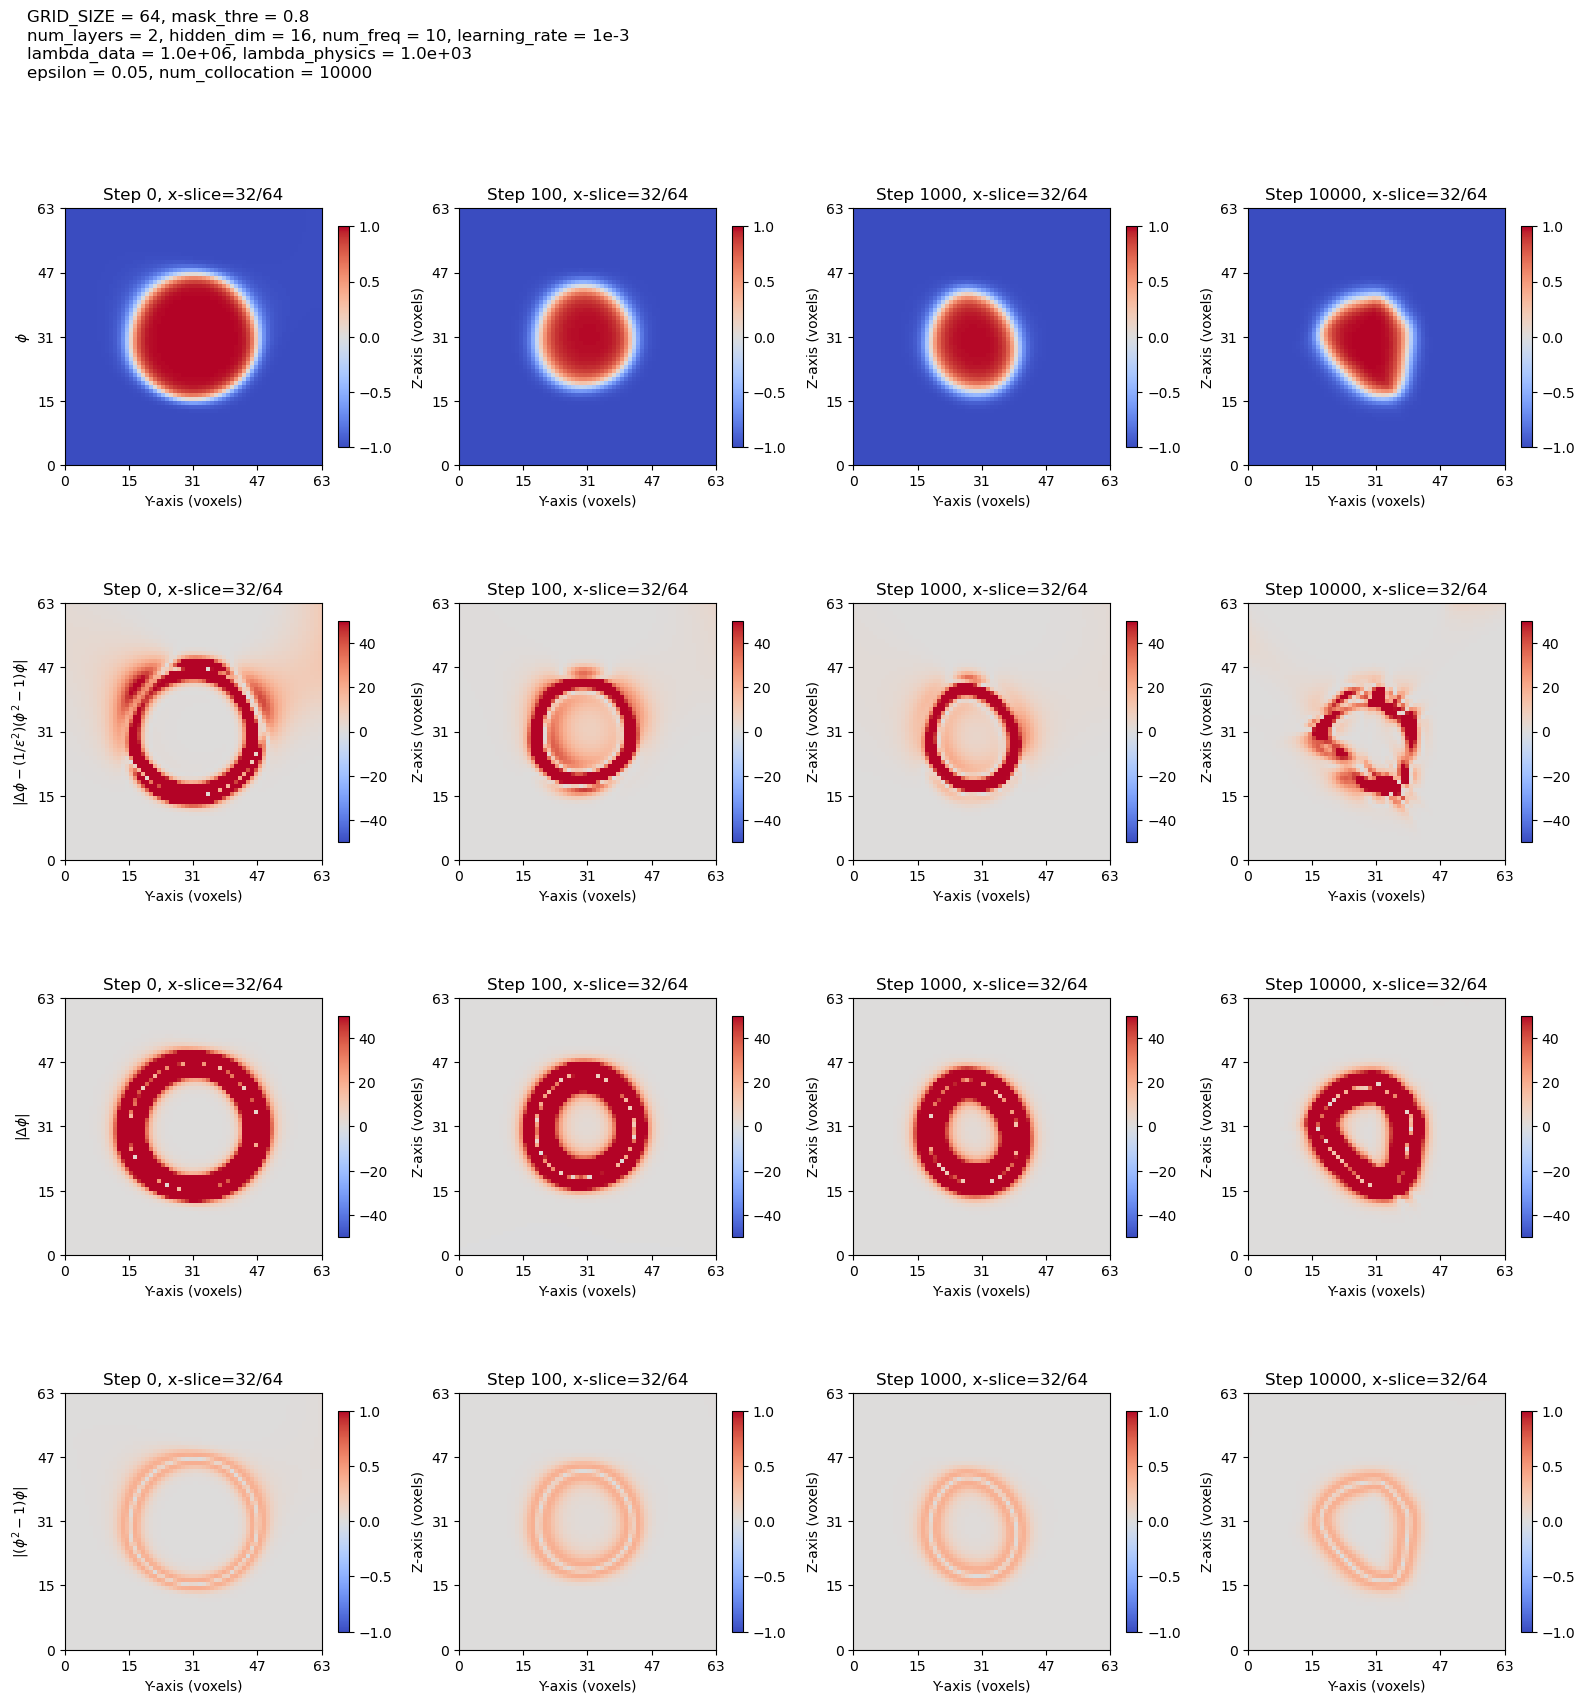

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    visualize_checkpoint_result,
    visualize_physics_loss,
)
from pinn.utils import assemble_loss_history

GRID_SIZE = 64
# lambda_1 = 5000000
# lambda_2 = 1
num_collocation = 10000
num_layers = 2
epsilon = 0.05

# steps_to_visualize = [0, 200, 600, 1000]
steps_to_visualize = [0, 100, 1000, 10000]


# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/experimental/lambda_{lambda_1}_{lambda_2}")
checkpoint_data = {}
for step in steps_to_visualize:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)


# Create a big figure with 4 rows: cryoET + contours, prediction result, 3D isosurface, and leave room for loss plots
fig = plt.figure(figsize=(4*4, 4*4))


# Row 1: Phi
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="phi",
                           grid_size=GRID_SIZE, slice_index=32, axis="x", vmin=-1, vmax=1)
    # visualize_checkpoint_result(ax, step, checkpoint_data[step], grid_size=GRID_SIZE, slice_index=32, axis="z", colorbar = True)
    if i == 0:
        ax.set_ylabel(r"$\phi$")

# Row 2: residual
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 4 + i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="residual",
                           grid_size=GRID_SIZE, slice_index=32, axis="x", vmin=-50, vmax=50)
    # visualize_physics_loss(ax, step, checkpoint_data[step], epsilon = epsilon, component = "residual", grid_size = GRID_SIZE, slice_index=32, axis="z", vmin=0, vmax=1e5)
    if i == 0:
        ax.set_ylabel(r"$|\Delta \phi - (1/\epsilon^2)(\phi^2 - 1)\phi|$")

# Row 3: laplacian
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 8 + i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="laplacian",
                           grid_size=GRID_SIZE, slice_index=32, axis="x", vmin=-50, vmax=50)
    # visualize_physics_loss(ax, step, checkpoint_data[step], epsilon = epsilon, component = "laplacian", grid_size = GRID_SIZE, slice_index=32, axis="z", vmin=0, vmax=1e5)
    if i == 0:
        ax.set_ylabel(r"$|\Delta \phi|$")

# Row 4: gradient
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 12 + i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           # checkpoint=checkpoint_data[step], component="grad_norm2",
                           checkpoint=checkpoint_data[step], component="nonlinear",
                           grid_size=GRID_SIZE, slice_index=32, axis="x", vmin=-1, vmax=1)
    if i == 0:
        ax.set_ylabel(r"$|(\phi^2 - 1)\phi|$")
        # ax.set_ylabel(r"$|\nabla\phi|^2$")


info_text = (
    f"GRID_SIZE = {GRID_SIZE}, mask_thre = 0.8\n"
    f"num_layers = {num_layers}, hidden_dim = 16, num_freq = 10, learning_rate = 1e-3\n"
    f"lambda_data = {lambda_1:.1e}, lambda_physics = {lambda_2:.1e}\n"
    f"epsilon = {epsilon}, num_collocation = {num_collocation}"
)

fig.text(
    0.02, 1.08,  # (x, y) position in figure coordinates
    info_text,
    fontsize=12,
    ha='left',
    va='top'
)

plt.tight_layout()
# plt.savefig("../outputs/figs/physics.png", dpi=300, bbox_inches="tight")
plt.show()